#EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Consumimos directamente el archivo CSV procesado en la etapa anterior
df_clean = pd.read_csv('/content/streaming_users_clean.csv')

##Visualizaciones Univariadas

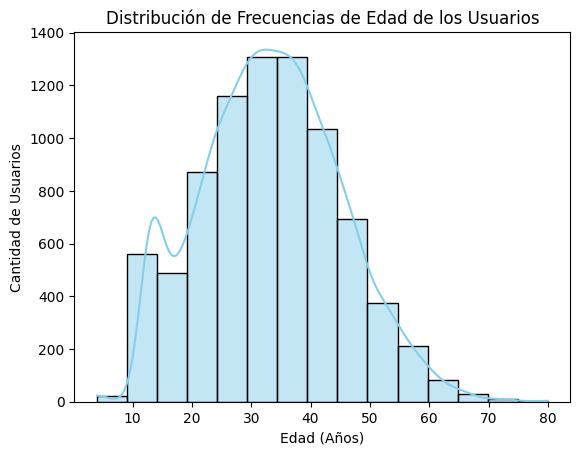

In [ ]:
sns.histplot(data=df_clean, x='age', bins=15, kde=True, color='skyblue')
plt.title('Distribución de Frecuencias de Edad de los Usuarios')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

### Interpretación del Histograma de Edad
Este histograma revela que la base de usuarios se concentra mayoritariamente en un rango de edad adulto joven, con un pico claro entre los **30 y 40 años**. La distribución es aproximadamente unimodal con un ligero sesgo hacia la derecha, mostrando una caída gradual en la cantidad de usuarios a partir de los 50 años. Esto confirma que el núcleo estratégico de consumo reside en el público adulto en edad laboral activa.

/tmp/ipykernel_4662/102259380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')


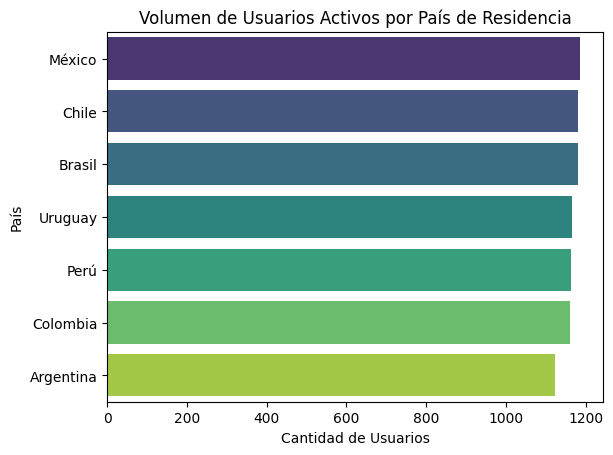

In [ ]:
# Contamos los países que ya fueron unificados y limpiados de errores de tipeo
country_counts = df_clean['country'].value_counts()
sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')
plt.title('Volumen de Usuarios Activos por País de Residencia')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('País')
plt.show()

### Análisis Geográfico Post-Limpieza
El gráfico de barras muestra una distribución **notablemente equitativa** entre los países de Latinoamérica, con México, Chile y Brasil liderando ligeramente el volumen de usuarios activos. Todos los países analizados superan los 1,100 usuarios, lo que permite realizar comparaciones estadísticas robustas y equilibradas entre regiones sin sesgos de representatividad significativos.

##Visualizaciones Bivariadas

/tmp/ipykernel_4662/2663151409.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='subscription_plan', y='monthly_watch_time_mins', palette='Set2')


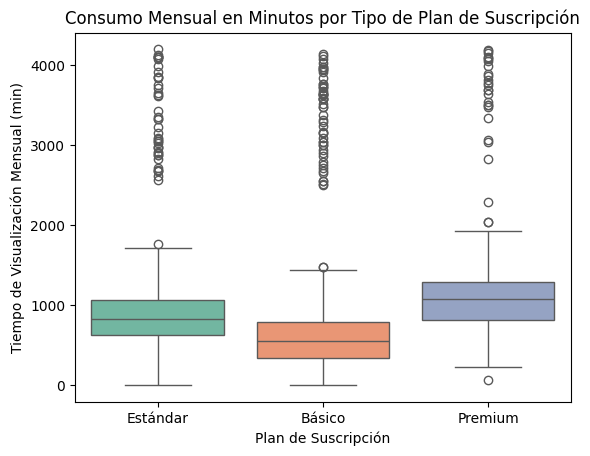

In [ ]:
sns.boxplot(data=df_clean, x='subscription_plan', y='monthly_watch_time_mins', palette='Set2')
plt.title('Consumo Mensual en Minutos por Tipo de Plan de Suscripción')
plt.xlabel('Plan de Suscripción')
plt.ylabel('Tiempo de Visualización Mensual (min)')
plt.show()

### Comparativa de Consumo por Plan
El diagrama de caja confirma una jerarquía clara en el consumo: los planes **Premium** y **Estándar** mantienen medianas de visualización mensual significativamente superiores (cerca de los 1,000 minutos) en comparación con el plan **Básico**. Aunque existen valores atípicos de alto consumo en todos los planes, la mayoría de los usuarios del plan Básico se concentran en niveles de visualización inferiores a los 800 minutos.

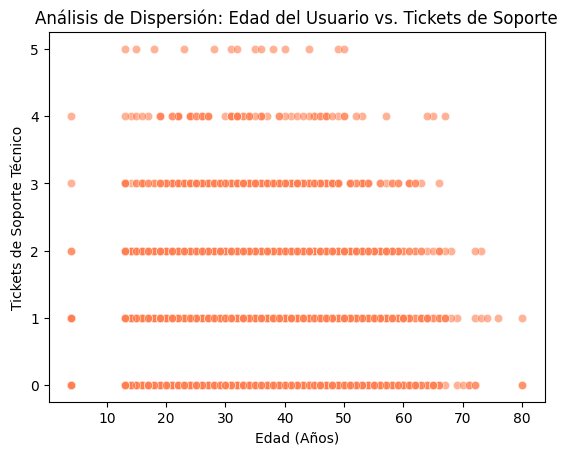

In [ ]:
# Usamos un scatter plot con un ligero "jitter" o transparencia si los puntos se solapan
sns.scatterplot(data=df_clean, x='age', y='customer_support_tickets', alpha=0.6, color='coral')
plt.title('Análisis de Dispersión: Edad del Usuario vs. Tickets de Soporte')
plt.xlabel('Edad (Años)')
plt.ylabel('Tickets de Soporte Técnico')
plt.show()

### Correlación: Edad vs. Soporte Técnico
Este análisis de dispersión es clave tras el proceso de depuración, donde se eliminó el outlier sistemático de '99' tickets y se aplicó **imputación por mediana** para completar registros faltantes. La nube de puntos resultante no muestra una tendencia lineal; esto valida que la complejidad técnica percibida o la necesidad de soporte no depende de la edad del usuario, sino de factores externos a su perfil demográfico.

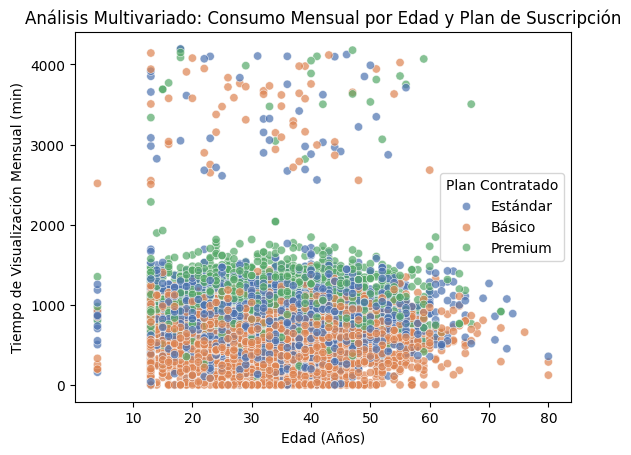

In [ ]:
# Agregamos una tercera variable categórica usando el parámetro 'hue' según la Clase 5
sns.scatterplot(data=df_clean, x='age', y='monthly_watch_time_mins', hue='subscription_plan', palette='deep', alpha=0.7)
plt.title('Análisis Multivariado: Consumo Mensual por Edad y Plan de Suscripción')
plt.xlabel('Edad (Años)')
plt.ylabel('Tiempo de Visualización Mensual (min)')
plt.legend(title='Plan Contratado')
plt.show()

### Conclusión del Análisis Multivariado
El análisis de dispersión por edad, consumo y plan confirma que el **tipo de suscripción** es el factor más determinante para el tiempo de visualización, independientemente de la edad del usuario. Se observa una estratificación horizontal donde los usuarios del plan Básico (naranja) predominan en la base del gráfico, mientras que los usuarios Premium (verde) y Estándar (azul) se distribuyen en rangos de consumo más elevados a lo largo de todas las edades.